In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, lfilter_zi

In [3]:
# Load data set and rename columns

data = pd.read_csv("./victory_gesture_motion_raw.csv")
df = pd.DataFrame(data)

new_cols = {}
for index, col in enumerate(df.columns):
    new_cols[col] = f"channel_{index}"

print(new_cols)

df = df.rename(columns=new_cols)
df.head()

{'-0.039063': 'channel_0', '-0.0078125': 'channel_1', '-0.03125': 'channel_2', '-0.015625': 'channel_3', '-0.015625.1': 'channel_4', '0.015625': 'channel_5', '-0.0078125.1': 'channel_6', '-0.015625.2': 'channel_7'}


,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7
0,-0.015625,-0.039063,-0.039063,-0.007812,-0.015625,0.007812,-0.023438,-0.007812
1,-0.015625,-0.031250,-0.023438,-0.023438,-0.031250,-0.015625,-0.007812,-0.007812
2,0.007812,0.054688,0.015625,0.000000,-0.007812,0.000000,-0.007812,0.000000
3,-0.015625,-0.046875,-0.023438,-0.007812,0.007812,-0.031250,-0.015625,-0.007812
4,0.000000,-0.015625,-0.023438,-0.015625,-0.007812,0.015625,0.000000,-0.015625


ValueError: x and y must have same first dimension, but have shapes (92045,) and (100,)

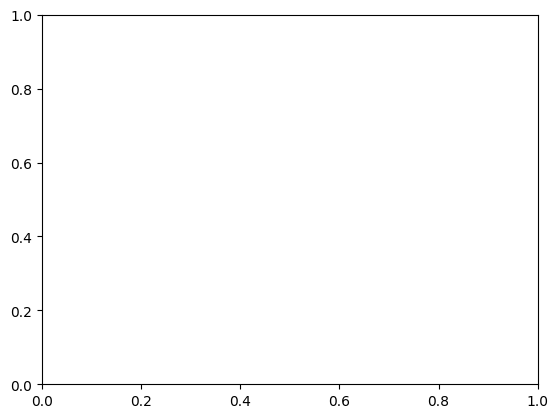

In [16]:
# work with channel 1 first
data_a = df.channel_0
FS = 1000

# plot data_point over time
# time = 1/fs where fs is the sampling frequency
time = np.linspace(0, len(data_a[0:100])/FS, num=data_a.size)
plt.plot(time, data_a[0:100])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")

max_amp = max(data_a)
min_amp = min(data_a)

# if the signals are correct the mean must be 0
print(f"Maximum Amplitude: {max_amp} mV")
print(f"Minimum Amplitude: {min_amp} mV")
print(f"Mean: {np.sum(data_a)/len(data_a)}")
print(f"Total Time: {len(data_a)/FS} secs")


Text(0, 0.5, 'Amplitude (mV)')

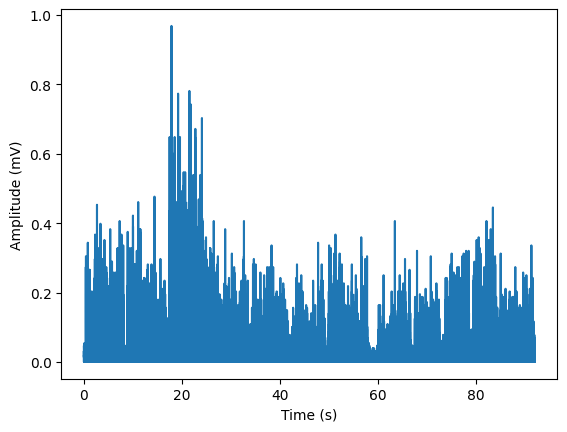

In [6]:
# Rectify and filter signal
data_a = np.abs(data_a)
plt.plot(time, data_a)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")

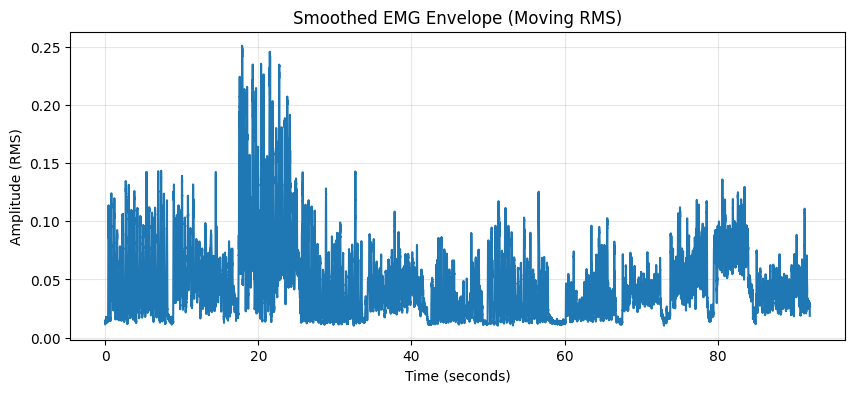

In [17]:
win_length = 50

def moving_rms(data, window_size):
    return np.sqrt(np.convolve(data**2, np.ones(window_size)/window_size, mode='same'))

rms_array = moving_rms(data_a, win_length)

total_time = len(data_a) / FS
time_rms = np.linspace(0, total_time, len(rms_array))

# 3. Plotting
plt.figure(figsize=(10, 4))
plt.plot(time_rms, rms_array)
plt.title("Smoothed EMG Envelope (Moving RMS)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (RMS)")
plt.grid(True, alpha=0.3)
plt.show()